# Stable PAR + spectrum capture

Reads the **reference TIA PAR sensor** and triggers a **MiniPAR spectral measurement**,
waits until *both* signals are stable, and appends the result to a CSV.

Schema written to disk:

```
timestamp,tia_par,metadata,f1_415,f2_445,f3_480,f4_515,f5_555,f6_590,f7_630,f8_680,clear,nir,gain,aint,astep
```

* `tia_par` — reference PAR from the TIA sensor (`getPAR()` over its REPL).
* `metadata` — free-text tag you type at capture time (filter, lamp, distance, ...).
* `f1_415 ... nir` — **raw ADC counts** from `spec_raw` (10 AS7341 channels, in device order).
* `gain`, `aint`, `astep` — the AS7341 `GAIN`/`ATIME`/`ASTEP` register values in force for that
  reading, from `spec_status`. Raw counts are meaningless without them:
  `basic_count = raw / (gain_multiplier * (aint+1) * (astep+1) * 2.78e-3)` - t_int in **ms**,
  the ams AN000633 §2.1 convention used by `as7341_calibrate.basic_counts()` and by
  firmware >= 1.06. Firmware <= 1.05 used the tick in seconds (`2.78e-6`).

**Stability rule** — over a rolling window of the last *N* samples, the peak-to-peak spread of
both the TIA PAR *and* the spectral total (sum of all 10 channels) must be within `STABLE_TOL`
of the window mean. A rolling window is used rather than "two consecutive readings agree",
because two samples can agree by chance while the lamp is still drifting.

Run the cells top to bottom; the capture loop is the one you keep coming back to.


## 1. Imports and configuration


In [13]:
import time
from collections import deque
from pathlib import Path

import numpy as np
import pandas as pd
import serial
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
from IPython.display import clear_output, display

# helpers.py stays in ../Scripts: it is shared with the pre-existing notebooks there.
import sys
sys.path.insert(0, '../Scripts')
from helpers import findDevice

BAUD_RATE = 115200

# --- CSV schema ------------------------------------------------------------
SPECTRAL_CHANNELS = ['f1_415', 'f2_445', 'f3_480', 'f4_515',
                     'f5_555', 'f6_590', 'f7_630', 'f8_680',
                     'clear',  'nir']
SETTING_COLUMNS = ['gain', 'aint', 'astep']   # aint == the AS7341 ATIME register
CSV_COLUMNS = ['timestamp', 'tia_par', 'metadata'] + SPECTRAL_CHANNELS + SETTING_COLUMNS
N_SPEC = len(SPECTRAL_CHANNELS)               # 10

# --- Where readings are stored --------------------------------------------
_here = Path.cwd()
DATA_DIR = _here.parent / 'data' if (_here.parent / 'data').is_dir() else _here
CSV_PATH = DATA_DIR / 'stable_par_spec.csv'

# --- Stability criterion ---------------------------------------------------
STABLE_WINDOW   = 4      # consecutive samples that must agree
STABLE_TOL      = 0.01   # 1 % peak-to-peak spread relative to the window mean
STABLE_MAX_WAIT = 60.0   # s, give up waiting after this
SETTLE_S        = 0.15   # pause between samples (a spec read already takes ~0.6 s)
TIA_ABS_FLOOR   = 0.05   # TIA ptp always treated as stable (keeps dark readings from spinning)
SPEC_ABS_FLOOR  = 8.0    # spectral-total ptp, raw counts, likewise

SATURATION_COUNT = 65535  # AS7341 full-scale raw count

print(f'CSV target : {CSV_PATH}')
print(f'Stability  : {STABLE_WINDOW} samples within {STABLE_TOL * 100:.1f} % on both signals')

CSV target : c:\Users\LudovicoCaracciolo\Documents\Git-repo\miniPar\data\stable_par_spec.csv
Stability  : 4 samples within 1.0 % on both signals


## 2. Find the two devices

The MiniPAR is scanned for **first**: the TIA probe sends a bare `\x01` to every port, which
would otherwise sit in the MiniPAR's line buffer and corrupt the next `hello`.


In [14]:
PORT_MINIPAR = None
PORT_REF = None

print('Scanning for MiniPAR...')
PORT_MINIPAR = findDevice(question="hello\n", answer="MiniPAR", flush=True, timeout=2)

print('\nScanning for reference sensor (TIA)...')
PORT_REF = findDevice(question="\x01", answer="raw", flush=True, timeout=2)
if PORT_REF:
    # Ctrl-B leaves the raw REPL, Ctrl-D soft-reboots so main.py (getPAR) is running again.
    with serial.Serial(PORT_REF, baudrate=BAUD_RATE) as ser:
        ser.write(b"\x02\x04")
        ser.flush()
    time.sleep(1.0)

print(f'\nPORT_MINIPAR: {PORT_MINIPAR}')
print(f'PORT_REF    : {PORT_REF}')


Scanning for MiniPAR...
Received message: SPIWP:0xee
mode:DIO, clock div:1
load:0x3fcd5810,len:0x438
load:0x403cc710,len:0x90c
load:0x403ce710,len:0x2624
entry 0x403cc710
[    92][E][Preferences.cpp:50] begin(): nvs_open failed: NOT_FOUND
[spectrometer-debug] reason=boot attempts=1 ack=1 as7343_id_ok=1 as7343_id=0x00 as7341_id_ok=1 as7341_id=0x24 result=AS7341 init_ok=1
Spectrometer detected: AS7341
No BME280 detected
Ready
MiniPAR,1.1,1.05, port: COM64
Found device at: COM64, answer: SPIWP:0xee
mode:DIO, clock div:1
load:0x3fcd5810,len:0x438
load:0x403cc710,len:0x90c
load:0x403ce710,len:0x2624
entry 0x403cc710
[    92][E][Preferences.cpp:50] begin(): nvs_open failed: NOT_FOUND
[spectrometer-debug] reason=boot attempts=1 ack=1 as7343_id_ok=1 as7343_id=0x00 as7341_id_ok=1 as7341_id=0x24 result=AS7341 init_ok=1
Spectrometer detected: AS7341
No BME280 detected
Ready
MiniPAR,1.1,1.05


Scanning for reference sensor (TIA)...
Received message: SPIWP:0xee
mode:DIO, clock div:1
load:0x3fcd5810

In [15]:
# Override here if auto-detection missed something, e.g.
# PORT_MINIPAR = 'COM7'
# PORT_REF     = 'COM5'

assert PORT_MINIPAR, 'PORT_MINIPAR not set'
assert PORT_REF, 'PORT_REF not set'
print(f'MiniPAR @ {PORT_MINIPAR}    TIA @ {PORT_REF}')


MiniPAR @ COM64    TIA @ COM66


## 3. Serial layer

Both ports are opened **once** and held open. Reopening per read re-asserts DTR/RTS, which
resets the ESP32-C3 and costs a second or more — unusable inside a stability loop.


In [16]:
class MiniPar:
    """Persistent line-mode connection to the MiniPAR (ESP32-C3, USB CDC).

    The firmware handles one command per newline-terminated line and always closes its
    reply with a newline (`main.cpp` -> `Serial.println()`), so a blocking `readline()`
    with a generous timeout is enough: no fixed sleeps, no reopening the port.
    """

    def __init__(self, port, baudrate=BAUD_RATE, timeout=3.0):
        self.ser = serial.Serial(port, baudrate=baudrate, timeout=timeout)
        self.ser.setDTR(False)          # keep the ESP32 out of bootloader mode
        self.ser.setRTS(False)
        time.sleep(0.3)
        self.ser.write(b'\n')           # terminate any partial line left in the firmware buffer
        self.ser.flush()
        time.sleep(0.1)
        self.ser.reset_input_buffer()

    def close(self):
        try:
            self.ser.close()
        except Exception:
            pass

    def cmd(self, text, retries=2):
        """Send one command, return its single-line reply (stripped)."""
        for _ in range(retries + 1):
            self.ser.reset_input_buffer()
            self.ser.write((text + '\n').encode())
            self.ser.flush()
            reply = self.ser.readline().decode(errors='ignore').strip()
            if reply:
                if reply.startswith('error:'):
                    raise RuntimeError(f'MiniPAR rejected {text!r}: {reply}')
                return reply
        raise RuntimeError(f'No reply from MiniPAR for {text!r} '
                           f'(timeout {self.ser.timeout} s)')

    def spec_raw(self):
        """`spec_raw` -> (raw ADC counts per channel, model name)."""
        reply = self.cmd('spec_raw')
        parts = [p.strip() for p in reply.split(',') if p.strip()]
        model = ''
        if parts and not (parts[0][0].isdigit() or parts[0][0] == '-'):
            model, parts = parts[0], parts[1:]
        if len(parts) != N_SPEC:
            raise RuntimeError(f'Expected {N_SPEC} channels, got {len(parts)}: {reply!r}')
        return np.array([float(p) for p in parts], dtype=float), model

    def status(self):
        """`spec_status` -> {'model': 'AS7341', 'available': 1, 'atime': .., 'astep': .., 'gain': ..}."""
        reply = self.cmd('spec_status')
        out = {}
        for field in reply.split(','):
            if '=' not in field:
                continue
            key, value = (s.strip() for s in field.split('=', 1))
            try:
                out[key] = int(value)
            except ValueError:
                out[key] = value
        return out

    def par(self, raw=False):
        """MiniPAR's own PAR estimate (`par` / `par_raw`) - not written to the CSV."""
        return float(self.cmd('par_raw' if raw else 'par'))

    def set_setting(self, name, value):
        """name in {'gain', 'atime', 'astep'}; returns the value the device echoes back."""
        if name not in {'gain', 'atime', 'astep'}:
            raise ValueError(f'unknown setting {name!r}')
        return int(self.cmd(f'spec_set_{name},{int(value)}'))


class TiaRef:
    """Persistent connection to the reference TIA PAR sensor (a MicroPython REPL).

    `getPAR()` is typed at the REPL, so the reply stream is: the echoed command, the
    printed value, then a bare `>>> ` prompt. Lines are read until one parses as a float
    rather than assuming a fixed echo count.
    """

    def __init__(self, port, baudrate=BAUD_RATE, timeout=2.0):
        self.ser = serial.Serial(port, baudrate=baudrate, timeout=timeout)
        time.sleep(0.2)
        self.ser.reset_input_buffer()

    def close(self):
        try:
            self.ser.close()
        except Exception:
            pass

    def par(self, max_lines=8):
        self.ser.reset_input_buffer()
        self.ser.write(b'getPAR()\r')
        self.ser.flush()
        seen = []
        for _ in range(max_lines):
            line = self.ser.readline().decode(errors='ignore').strip()
            if not line:
                continue
            seen.append(line)
            token = line.replace('>>>', '').replace('getPAR()', '').strip()
            if not token:
                continue
            try:
                return float(token)
            except ValueError:
                continue
        raise RuntimeError(f'No numeric PAR from the TIA sensor; saw {seen!r}')


def gain_multiplier(gain_reg):
    """AS7341 GAIN register -> multiplier: 0 -> 0.5x, n -> 2**(n-1). Mirrors the firmware."""
    gain_reg = int(gain_reg)
    return 0.5 if gain_reg == 0 else float(1 << (gain_reg - 1))


MP = None
TIA = None


def close_links():
    global MP, TIA
    for link in (MP, TIA):
        if link is not None:
            link.close()
    MP = TIA = None


def open_links():
    """(Re)open both ports. Safe to re-run - existing handles are closed first."""
    global MP, TIA
    close_links()
    MP = MiniPar(PORT_MINIPAR)
    TIA = TiaRef(PORT_REF)
    return MP, TIA


open_links()
print('MiniPAR :', MP.cmd('hello'))
print('status  :', MP.status())
print('TIA PAR :', TIA.par())


MiniPAR : MiniPAR,1.1,1.05
status  : {'model': 'AS7341', 'available': 1, 'atime': 100, 'astep': 999, 'gain': 2}
TIA PAR : 2959.8864


## 4. Stability-gated read

`read_stable()` samples the TIA and the spectrometer in lockstep and only returns once the
rolling window is quiet on **both**. It also:

* re-reads `spec_status` afterwards and refuses the capture if `gain`/`aint`/`astep` moved
  mid-run,
* flags any channel that hit full scale (65535) so a saturated spectrum is never saved
  silently,
* aggregates the accepted window with a per-channel **median** (all its samples are within
  tolerance by construction, so this is free noise reduction — pass `aggregate='last'` for
  the raw final sample instead).

A relative tolerance alone cannot settle near darkness, where a fraction of a count is an
infinite relative change; `TIA_ABS_FLOOR` / `SPEC_ABS_FLOOR` give it an absolute escape hatch.


In [17]:
def _spread(values, abs_floor):
    """Peak-to-peak spread of a window -> (spread relative to its mean, within absolute floor)."""
    a = np.asarray(values, dtype=float)
    ptp = float(np.ptp(a))
    mean = float(np.mean(np.abs(a)))
    rel = ptp / mean if mean > 1e-12 else np.inf
    return rel, ptp <= abs_floor


def read_stable(mp=None, tia=None, window=STABLE_WINDOW, tol=STABLE_TOL,
                max_wait_s=STABLE_MAX_WAIT, settle_s=SETTLE_S,
                aggregate='median', verbose=True):
    """Sample TIA PAR + MiniPAR spectrum until both signals hold steady.

    Returns a dict: tia_par, spec (10 raw counts), model, gain/aint/astep, the stability
    diagnostics, and the full sampling history for plotting.
    """
    mp = mp if mp is not None else MP
    tia = tia if tia is not None else TIA
    if mp is None or tia is None:
        raise RuntimeError('Serial links are closed - run open_links() first.')

    settings_before = mp.status()

    tia_hist = deque(maxlen=window)     # accepted window
    spec_hist = deque(maxlen=window)
    tia_all, total_all = [], []         # full history, for the convergence plot
    t0 = time.monotonic()
    n = 0
    rel_tia = rel_sum = np.inf
    stable = False
    model = ''

    while True:
        tia_value = tia.par()
        spec, model = mp.spec_raw()
        tia_hist.append(tia_value)
        spec_hist.append(spec)
        tia_all.append(tia_value)
        total_all.append(float(spec.sum()))
        n += 1

        if len(tia_hist) == window:
            totals = [float(s.sum()) for s in spec_hist]
            rel_tia, tia_flat = _spread(tia_hist, TIA_ABS_FLOOR)
            rel_sum, sum_flat = _spread(totals, SPEC_ABS_FLOOR)
            stable = (rel_tia <= tol or tia_flat) and (rel_sum <= tol or sum_flat)
            if verbose:
                print(f'  [{n:3d}] {time.monotonic() - t0:5.1f} s   '
                      f'TIA {tia_value:10.4f} (spread {rel_tia * 100:6.2f} %)   '
                      f'spec total {total_all[-1]:9.0f} (spread {rel_sum * 100:6.2f} %)')
            if stable:
                if verbose:
                    print(f'  -> stable after {n} samples / {time.monotonic() - t0:.1f} s')
                break
        elif verbose:
            print(f'  [{n:3d}] filling window ({len(tia_hist)}/{window})')

        if time.monotonic() - t0 > max_wait_s:
            print(f'  WARNING: not stable within {tol * 100:.1f} % after {max_wait_s:.0f} s '
                  f'- returning the last window anyway.')
            break

        time.sleep(settle_s)

    settings_after = mp.status()
    drifted = [k for k in ('gain', 'atime', 'astep')
               if settings_before.get(k) != settings_after.get(k)]
    if drifted:
        raise RuntimeError(f'Spectrometer settings changed mid-capture ({", ".join(drifted)}): '
                           f'{settings_before} -> {settings_after}')

    spec_arr = np.vstack(spec_hist)
    if aggregate == 'median':
        spec_out = np.median(spec_arr, axis=0)
        tia_out = float(np.median(np.asarray(tia_hist, dtype=float)))
    elif aggregate == 'last':
        spec_out = spec_arr[-1]
        tia_out = float(tia_hist[-1])
    else:
        raise ValueError(f"aggregate must be 'median' or 'last', got {aggregate!r}")

    saturated = [name for name, peak in zip(SPECTRAL_CHANNELS, spec_arr.max(axis=0))
                 if peak >= SATURATION_COUNT]

    return {
        'tia_par': tia_out,
        'spec': spec_out,
        'model': model,
        'gain': settings_after.get('gain'),
        'aint': settings_after.get('atime'),
        'astep': settings_after.get('astep'),
        'stable': bool(stable),
        'saturated': saturated,
        'n_samples': n,
        'elapsed_s': round(time.monotonic() - t0, 2),
        'tia_spread': rel_tia,
        'spec_spread': rel_sum,
        'tia_history': tia_all,
        'total_history': total_all,
    }


print('read_stable() ready.')


read_stable() ready.


In [18]:
# Smoke test: one stability-gated read, nothing written to disk.
test_reading = read_stable()
print()
for key in ('tia_par', 'model', 'gain', 'aint', 'astep',
            'stable', 'saturated', 'n_samples', 'elapsed_s'):
    print(f'{key:12s}: {test_reading[key]}')
print(f'{"spec":12s}: {dict(zip(SPECTRAL_CHANNELS, test_reading["spec"]))}')


  [  1] filling window (1/4)
  [  2] filling window (2/4)
  [  3] filling window (3/4)
  [  4]   2.9 s   TIA  1908.7296 (spread   0.01 %)   spec total       138 (spread   0.73 %)
  -> stable after 4 samples / 2.9 s

tia_par     : 1908.59424
model       : AS7341
gain        : 2
aint        : 100
astep       : 999
stable      : True
saturated   : []
n_samples   : 4
elapsed_s   : 2.92
spec        : {'f1_415': 3.0, 'f2_445': 6.0, 'f3_480': 10.5, 'f4_515': 12.0, 'f5_555': 12.0, 'f6_590': 13.0, 'f7_630': 17.0, 'f8_680': 15.0, 'clear': 41.0, 'nir': 8.0}


## 5. Acquisition settings (optional)

`gain` / `aint` / `astep` are saved with every row, so change them here whenever the light
level needs a different exposure — then re-run the capture loop.

* `gain` — GAIN register `0..10` → 0.5×, 1×, 2×, 4× … 512×
* `aint` — ATIME register `0..255`
* `astep` — ASTEP register `0..65534`
* integration time = `(aint + 1) * (astep + 1) * 2.78 µs`


In [19]:
# Uncomment to change; each call returns the value the device echoes back.
# print('gain  ->', MP.set_setting('gain', 4))
# print('atime ->', MP.set_setting('atime', 100))
# print('astep ->', MP.set_setting('astep', 999))

s = MP.status()
print(s)
print(f"-> gain x{gain_multiplier(s['gain']):g}, "
      f"integration {(s['atime'] + 1) * (s['astep'] + 1) * 2.78e-6:.4f} s")


{'model': 'AS7341', 'available': 1, 'atime': 100, 'astep': 999, 'gain': 2}
-> gain x2, integration 0.2808 s


## 6. CSV storage


In [20]:
def load_readings(path=CSV_PATH):
    """Read the CSV into a DataFrame with exactly CSV_COLUMNS, or an empty one."""
    path = Path(path)
    if not path.exists():
        return pd.DataFrame(columns=CSV_COLUMNS)
    df = pd.read_csv(path)
    missing = [c for c in CSV_COLUMNS if c not in df.columns]
    if missing:
        raise RuntimeError(f'{path} is missing columns {missing} - it was written with a '
                           f'different schema. Point CSV_PATH at a new file, or migrate it.')
    return df[CSV_COLUMNS]


def append_reading(row, path=CSV_PATH):
    """Append one row, writing the header only when creating the file."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    frame = pd.DataFrame([row], columns=CSV_COLUMNS)
    frame.to_csv(path, mode='a', index=False, header=not path.exists())
    return frame


def reading_to_row(reading, metadata):
    """read_stable() result + a tag -> one CSV row."""
    row = {'timestamp': pd.Timestamp.now().isoformat(timespec='seconds'),
           'tia_par': float(reading['tia_par']),
           'metadata': metadata}
    row.update({name: float(v) for name, v in zip(SPECTRAL_CHANNELS, reading['spec'])})
    row.update({'gain': int(reading['gain']),
                'aint': int(reading['aint']),
                'astep': int(reading['astep'])})
    return row


print(f'{len(load_readings())} reading(s) currently in {CSV_PATH}')


4 reading(s) currently in c:\Users\LudovicoCaracciolo\Documents\Git-repo\miniPar\data\stable_par_spec.csv


## 7. Plots

Two views, shown side by side after every capture:

* **Normalised spectra** — every saved row plus the live one, each divided by its own total so
  shapes are comparable across intensities. Rows are coloured by their TIA PAR on a single
  perceptually-uniform ramp with a colourbar; PAR is a magnitude, and one categorical hue per
  row stops working past ~8 rows. The live reading is the only categorical mark: black,
  thicker, direct-labelled.
* **Convergence** — both signals over the whole settling run, each divided by its own final
  value so they share one y-axis. The shaded band is the window that satisfied the tolerance.


In [21]:
SURFACE   = '#ffffff'
INK       = '#1b1b1b'
INK_MUTED = '#8a8a8a'
GRID      = '#e6e6e6'
BAND      = '#dcdcdc'
C_TIA     = '#2f6fd0'     # validated pair: normal-vision dE 30.5, worst-CVD dE 26.0
C_SPEC    = '#c2571a'
SEQ_CMAP  = plt.colormaps['viridis']


def _style(ax):
    ax.set_facecolor(SURFACE)
    ax.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK_MUTED, labelsize=9)
    ax.xaxis.label.set_color(INK_MUTED)
    ax.yaxis.label.set_color(INK_MUTED)
    ax.title.set_color(INK)


def plot_spectra(df, current=None, current_label=None, ax=None):
    """Normalised spectra of every saved row, plus an optional live reading."""
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(11, 6))
    fig = ax.figure

    x = np.arange(1, N_SPEC + 1)
    mappable = None

    if df is not None and not df.empty:
        counts = df[SPECTRAL_CHANNELS].apply(pd.to_numeric, errors='coerce')
        totals = counts.sum(axis=1).replace(0, np.nan)
        shapes = counts.div(totals, axis=0)
        par = pd.to_numeric(df['tia_par'], errors='coerce').to_numpy(dtype=float)

        finite = par[np.isfinite(par)]
        vmin = float(finite.min()) if finite.size else 0.0
        vmax = float(finite.max()) if finite.size else 1.0
        if vmax <= vmin:
            vmax = vmin + 1.0
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

        for (_, row), value in zip(shapes.iterrows(), par):
            colour = SEQ_CMAP(norm(value)) if np.isfinite(value) else INK_MUTED
            ax.plot(x, row.to_numpy(dtype=float), linewidth=1.6, marker='o', markersize=4,
                    color=colour, alpha=0.85, zorder=2)
        mappable = plt.cm.ScalarMappable(norm=norm, cmap=SEQ_CMAP)

    if current is not None:
        cur = np.asarray(current, dtype=float)[:N_SPEC]
        total = cur.sum()
        if total:
            cur = cur / total
        ax.plot(x, cur, linewidth=2.6, marker='o', markersize=7, color=INK, zorder=3,
                label=current_label or 'current reading',
                path_effects=[pe.Stroke(linewidth=5, foreground=SURFACE), pe.Normal()])
        ax.legend(frameon=False, loc='best', fontsize=9, labelcolor=INK)

    n_saved = 0 if df is None else len(df)
    ax.set_xticks(x)
    ax.set_xticklabels(SPECTRAL_CHANNELS, rotation=45, ha='right')
    ax.set_xlabel('channel')
    ax.set_ylabel('fraction of total counts')
    ax.set_title(f'Normalised spectra - {n_saved} saved reading(s)', fontsize=12)
    _style(ax)

    if mappable is not None:
        bar = fig.colorbar(mappable, ax=ax, pad=0.02)
        bar.set_label('TIA PAR', color=INK_MUTED, fontsize=9)
        bar.ax.tick_params(colors=INK_MUTED, labelsize=8)
        bar.outline.set_visible(False)

    if own_fig:
        fig.patch.set_facecolor(SURFACE)
        plt.tight_layout()
        plt.show()


def plot_convergence(reading, ax=None):
    """TIA PAR and spectral total over the settling run, both scaled to their final value."""
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(7, 6))
    fig = ax.figure

    tia = np.asarray(reading['tia_history'], dtype=float)
    total = np.asarray(reading['total_history'], dtype=float)
    n = np.arange(1, len(tia) + 1)

    def scaled(a):
        ref = a[-1]
        return a / ref if abs(ref) > 1e-12 else a

    accepted = min(STABLE_WINDOW, reading['n_samples'])
    if accepted > 1:
        ax.axvspan(reading['n_samples'] - accepted + 1, reading['n_samples'],
                   color=BAND, alpha=0.55, zorder=0,
                   label=f'accepted window ({accepted} samples)')
    ax.axhline(1.0, color=GRID, linewidth=1.0, zorder=1)
    ax.plot(n, scaled(tia), linewidth=2, marker='o', markersize=5,
            color=C_TIA, label='TIA PAR', zorder=3)
    ax.plot(n, scaled(total), linewidth=2, marker='o', markersize=5,
            color=C_SPEC, label='spec total', zorder=2)

    verdict = 'stable' if reading['stable'] else 'NOT stable'
    ax.set_xlabel('sample')
    ax.set_ylabel('value / final value')
    ax.set_title(f"Convergence - {verdict} after {reading['n_samples']} samples "
                 f"({reading['elapsed_s']:.1f} s)", fontsize=12)
    ax.legend(frameon=False, loc='best', fontsize=9, labelcolor=INK)
    _style(ax)

    if own_fig:
        fig.patch.set_facecolor(SURFACE)
        plt.tight_layout()
        plt.show()


def show_capture(df, reading):
    fig, (ax_spec, ax_conv) = plt.subplots(1, 2, figsize=(16, 6),
                                           gridspec_kw={'width_ratios': [1.35, 1]})
    plot_spectra(df, current=reading['spec'],
                 current_label=f"current @ TIA {reading['tia_par']:.2f}", ax=ax_spec)
    plot_convergence(reading, ax=ax_conv)
    fig.patch.set_facecolor(SURFACE)
    plt.tight_layout()
    plt.show()


print('Plot helpers ready.')


Plot helpers ready.


## 8. Capture loop

Press **Enter** to take a stability-gated reading. Review the plots and the printed
diagnostics, then type a **metadata tag** to save it — or leave it blank to throw it away.
Type `q` to leave the loop (the ports stay open, so you can just re-run this cell).


Saved to c:\Users\LudovicoCaracciolo\Documents\Git-repo\miniPar\data\stable_par_spec.csv  (5 rows total)


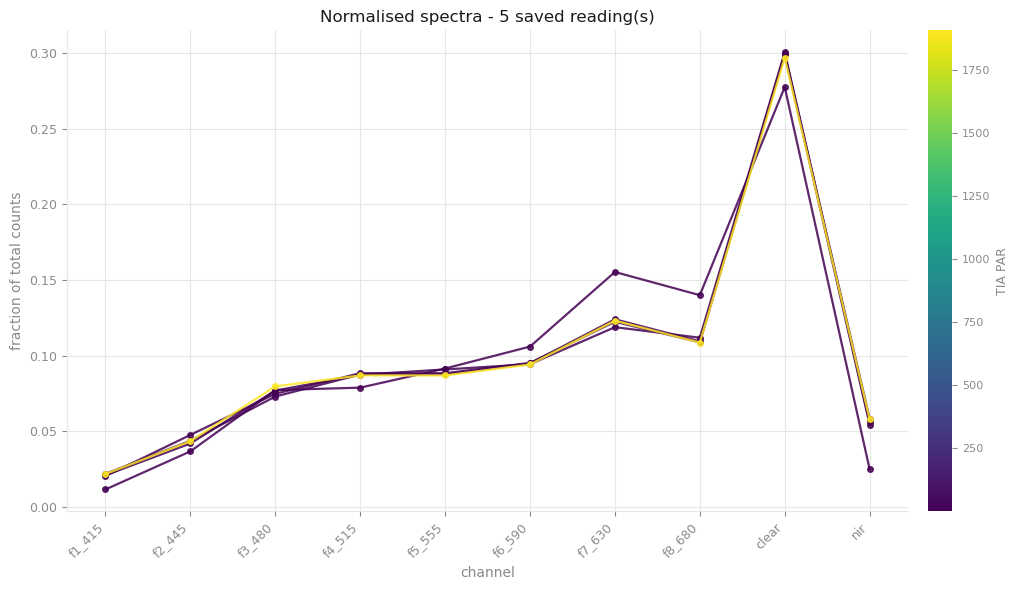

Left the capture loop. Serial ports are still open.


In [22]:
readings_df = load_readings()
print(f'{len(readings_df)} reading(s) already in {CSV_PATH}')
if not readings_df.empty:
    plot_spectra(readings_df)

while True:
    key = input('[Enter] capture   |   q + [Enter] quit : ').strip().lower()
    if key in {'q', 'quit', 'exit', 'esc'}:
        print('Left the capture loop. Serial ports are still open.')
        break

    try:
        reading = read_stable(verbose=True)
    except Exception as exc:
        print(f'Read failed: {exc}')
        continue

    clear_output(wait=True)
    show_capture(readings_df, reading)

    print(f"TIA PAR    : {reading['tia_par']:.4f}")
    print(f"spec total : {reading['spec'].sum():.0f} counts   "
          f"(gain={reading['gain']}, aint={reading['aint']}, astep={reading['astep']}, "
          f"model={reading['model']})")
    print(f"stability  : {'OK' if reading['stable'] else 'NOT REACHED'} - "
          f"{reading['n_samples']} samples in {reading['elapsed_s']:.1f} s, "
          f"TIA spread {reading['tia_spread'] * 100:.2f} %, "
          f"spec spread {reading['spec_spread'] * 100:.2f} %")
    if reading['saturated']:
        print(f"SATURATED  : {', '.join(reading['saturated'])} hit full scale - "
              f"lower gain or aint before saving")
    if not reading['stable']:
        print('WARNING    : the light source was still drifting when this was taken.')

    metadata = input('metadata tag to save this reading (blank = discard): ').strip()
    if not metadata:
        print('Discarded.')
        continue

    row = reading_to_row(reading, metadata)
    append_reading(row)
    readings_df = pd.concat([readings_df, pd.DataFrame([row], columns=CSV_COLUMNS)],
                            ignore_index=True)
    clear_output(wait=True)
    print(f'Saved to {CSV_PATH}  ({len(readings_df)} rows total)')
    plot_spectra(readings_df)


## 9. Review what was collected


5 rows in c:\Users\LudovicoCaracciolo\Documents\Git-repo\miniPar\data\stable_par_spec.csv


,timestamp,tia_par,metadata,f1_415,f2_445,f3_480,f4_515,f5_555,f6_590,f7_630,f8_680,clear,nir,gain,aint,astep
0,2026-08-10T11:52:15,0.002963,office,3.0,7.0,11.0,13.0,13.0,14.0,18.0,16.0,44.0,8.0,2,100,999
1,2026-08-10T11:53:12,0.002963,office,3.0,6.0,11.0,12.5,13.0,13.5,17.0,16.0,43.0,8.0,2,100,999
2,2026-08-10T11:53:58,0.002963,office led,182.0,578.0,1215.0,1240.5,1439.5,1667.5,2443.0,2202.0,4366.5,391.5,2,100,999
3,2026-08-10T12:06:23,14.328913,licor,3.0,6.0,10.0,12.0,12.0,13.0,17.0,15.0,41.0,8.0,2,100,999
4,2026-08-10T12:08:04,1908.774800,licor light,3.0,6.0,11.0,12.0,12.0,13.0,17.0,15.0,41.0,8.0,2,100,999



Rows per acquisition setting:


,,,rows
gain,aint,astep,
2,100,999,5


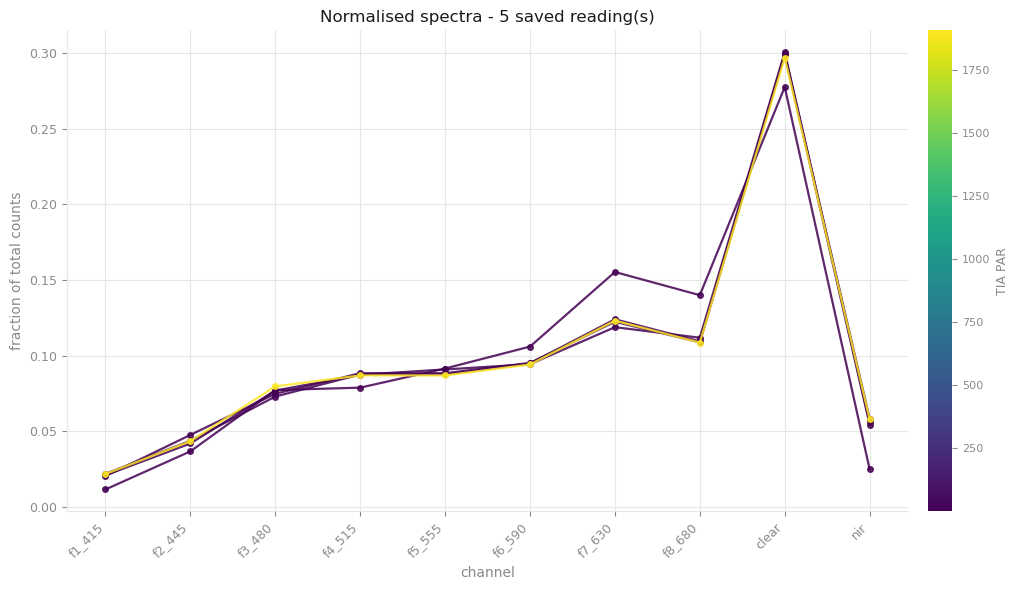

In [23]:
df = load_readings()
if df.empty:
    print(f'No readings yet in {CSV_PATH}')
else:
    print(f'{len(df)} rows in {CSV_PATH}')
    display(df.tail(10))

    print('\nRows per acquisition setting:')
    display(df.groupby(['gain', 'aint', 'astep']).size().rename('rows').to_frame())

    saturated = (df[SPECTRAL_CHANNELS] >= SATURATION_COUNT).any(axis=1)
    if saturated.any():
        print(f'\n{int(saturated.sum())} row(s) contain a saturated channel:')
        display(df.loc[saturated, ['timestamp', 'metadata', 'tia_par'] + SETTING_COLUMNS])

    plot_spectra(df)


## 10. Release the serial ports


In [24]:
close_links()
print('Serial ports closed. Re-run open_links() to reconnect.')


Serial ports closed. Re-run open_links() to reconnect.
